# Compare pool metrics
Load all metrics parquets from `artifacts/` and compare MAE, RMSE, MAPE across models (baseline, lstm, xgboost, lightgbm, ridge, xgb_lstm_stack, stack_simple_avg, stack_ridge_meta, stack_ridge_meta_logreturn, chronos_returns, chronos_price).

In [9]:
from pathlib import Path
import pandas as pd

ARTIFACTS_DIR = Path.cwd() / "artifacts"

files = {
    "baseline": "metrics_baseline_pool.parquet",
    "lstm": "metrics_lstm_pool.parquet",
    "xgboost": "metrics_xgboost_pool.parquet",
    "lightgbm": "metrics_lightgbm_pool.parquet",
    "ridge": "metrics_elasticnet_pool.parquet",
    "xgb_lstm_stack": "metrics_xgb_lstm_stack_pool.parquet",
    "stack_simple_avg": "metrics_stack_simple_avg_pool.parquet",
    "stack_ridge_meta": "metrics_stack_ridge_meta_pool.parquet",
    "stack_ridge_meta_logreturn": "metrics_stack_ridge_meta_logreturn_pool.parquet",
    "chronos_returns": "metrics_chronos_pool.parquet",
    "chronos_price": "metrics_chronos_pool_price.parquet",
}
dfs = []
for name, f in files.items():
    p = ARTIFACTS_DIR / f
    if p.exists():
        df = pd.read_parquet(p).copy()
        df["model"] = name
        dfs.append(df)
    else:
        print(f"Missing: {p}")

if not dfs:
    raise SystemExit("No metrics files found. Run 01–04 pool notebooks first.")
all_metrics = pd.concat(dfs, ignore_index=True)
print("Overall :")
overall = all_metrics[all_metrics["symbol"] == "overall"].sort_values('RMSE')
overall

Overall :


,model,symbol,MAE,RMSE,MAPE_%
120,chronos_price,overall,9.564310,13.022071,3.693424
98,stack_ridge_meta_logreturn,overall,9.551412,13.313249,3.650875
87,stack_ridge_meta,overall,9.576647,13.506070,3.641553
54,ridge,overall,9.745397,13.729269,3.701611
65,xgb_lstm_stack,overall,9.760875,13.749994,3.675405
76,stack_simple_avg,overall,9.848640,13.785472,3.728432
10,baseline,overall,10.796055,13.865619,4.161178
43,lightgbm,overall,9.844500,13.944012,3.679028
32,xgboost,overall,9.953546,14.030967,3.699016
109,chronos_returns,overall,10.243321,14.304265,3.836549


In [10]:
all_metrics

,model,symbol,MAE,RMSE,MAPE_%
0,baseline,AAPL,9.698705,11.500091,3.673588
1,baseline,MSFT,18.451262,22.183884,4.267448
2,baseline,GOOGL,11.865465,13.372779,3.653935
3,baseline,AMZN,10.424299,12.661312,4.608247
4,baseline,JPM,12.698524,14.034067,4.001225
...,...,...,...,...,...
116,chronos_price,WMT,3.756565,4.487598,3.093934
117,chronos_price,SPY,5.607280,6.707737,0.816415
118,chronos_price,XOM,7.582960,8.854527,5.517165
119,chronos_price,NVDA,4.281290,5.235963,2.327393


In [11]:
# Pivot: rows = symbol (or overall), columns = model, values = MAE / RMSE / MAPE_%
for metric in ["MAE", "RMSE", "MAPE_%"]:
    if metric not in all_metrics.columns:
        continue
    pt = all_metrics.pivot_table(index="symbol", columns="model", values=metric)
    print(f"\n--- {metric} ---")
    print(pt.to_string())
    print()


--- MAE ---
model     baseline  chronos_price  chronos_returns   lightgbm       lstm      ridge  stack_ridge_meta  stack_ridge_meta_logreturn  stack_simple_avg  xgb_lstm_stack    xgboost
symbol                                                                                                                                                                        
AAPL      9.698705      11.831006        12.788003  12.499856  12.261886  11.558540         12.070013                   11.886781         13.249438       12.075927  12.584117
AMZN     10.424299      10.717157        10.743629  10.562543  11.735594  10.335203         10.301030                   10.536753         11.286124       10.596367  10.461773
GOOGL    11.865465      11.495952        11.449230  10.469497   8.782062  10.507255         10.362352                   10.366304         11.228748       10.698304  10.312089
JNJ      11.604979       9.587438         8.483695   8.061774   9.564905   8.964954          8.284186           

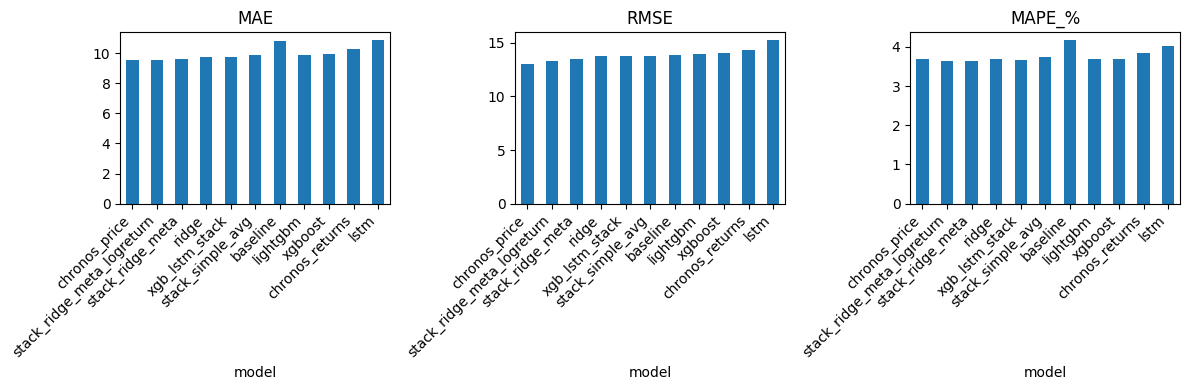

In [12]:
# Overall row only: bar comparison

if overall.empty:
    overall = all_metrics.groupby("model").agg({"MAE": "mean", "RMSE": "mean", "MAPE_%": "mean"}).reset_index()

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["MAE", "RMSE", "MAPE_%"]):
    if col in overall.columns:
        overall.plot(x="model", y=col, kind="bar", ax=ax, legend=False)
        ax.set_title(col)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()